# SU(2)

*Aug 17, 2026*

Updated *Sep 26, 2026*


**[Javad Komijani](mailto:jkomijani@gmail.com)**

Train (or load) a normalizing-flow model for 2D SU(2) lattice gauge theory with a plaquette (Wilson) action, sample gauge configurations, and cross-check observables (Wilson loops) against an independent HMC run.

Flow samples are drawn independently per plaquette using [normflow](https://github.com/jkomijani/normflow), then stitched into link variables via holonomies (Part A). A Metropolis-Hastings accept/reject step is applied to correct the raw flow distribution toward the target (Part B).

## Requirements

This notebook was run with the following package versions:

- [lattice_ml](https://github.com/jkomijani/lattice_ml) **v0.2.0**
  (commit [`843f412`](https://github.com/jkomijani/lattice_ml/commit/843f4121e1a0182de480678e6859733f8eaa6d71))
- [normflow](https://github.com/jkomijani/normflow) **v3.0.0**
  (commit [`6f824df`](https://github.com/jkomijani/normflow/commit/6f824df1f2b26134b737c3aafc77779ec1b0ca28))

To install exactly these versions:

    pip install git+https://github.com/jkomijani/normflow@v3.0.0
    pip install git+https://github.com/jkomijani/lattice_ml@v0.2.0

In [ ]:
import lattice_ml, normflow
print(f"lattice_ml {lattice_ml.__version__}, normflow {normflow.__version__}")
if (lattice_ml.__version__, normflow.__version__) != ("0.2.0", "3.0.0"):
    print("Warning: this notebook was run with lattice_ml 0.2.0 and normflow 3.0.0.")

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
torch.set_default_dtype(torch.float64)

In [3]:
torch.manual_seed(42 * 4);

In [4]:
grab = lambda z: z.detach().cpu().numpy()

In [5]:
from normflow import Model as NormflowModel

from normflow.action import MatrixAction

from normflow.prior import UniformSUnPrior

### Model

A single-plaquette prior (uniform on SU(2)) is transformed by a spline-based flow network into samples of the target (Wilson) plaquette distribution.

In [6]:
from normflow.nn import MultiChannelModule_
from normflow.nn import MatrixModule_
from normflow.nn import RQSplineNet_

from normflow.lib.matrix_handles import SU2MatrixParametrizer
from normflow.lib.matrix_handles import SU3MatrixParametrizer


def assemble_net(n_c: int, num_spline_segments: int):
    """
    Build a network based on Pade22 (RQ) spline.

    Returns:
        Module: parameter network with:
        - n_c == 2 (SU(2)): one angle (θ) → one RQ spline
        - n_c == 3 (SU(3)): two angles (θ, φ) → two-channel RQ spline
    """
    assert 1 < n_c < 4
    
    if n_c == 2:
        param_net_ = RQSplineNet_(num_spline_segments, smooth=True)
        matrix_handle = SU2MatrixParametrizer()

    else:
        net_theta_ = RQSplineNet_(num_spline_segments, smooth=True)
        net_phi_ = RQSplineNet_(
            num_spline_segments // 2, symmetric=True, smooth=True
        )
        param_net_ = MultiChannelModule_(
            [net_theta_, net_phi_], channels_axis=-1
        )
        matrix_handle = SU3MatrixParametrizer()

    return MatrixModule_(param_net_, matrix_handle=matrix_handle)

In [7]:
def make_normflow_model(n_c, beta, num_spline_segments):
    # Define the prior distribution
    prior = UniformSUnPrior(n=n_c)
    
    # Define the action
    action = MatrixAction(beta=beta)
    
    # Initialize the neural network for transformations
    net_ = assemble_net(n_c, num_spline_segments)
    
    # Create the Model with the defined components
    model = NormflowModel(network_fn_=net_, prior=prior, action=action)

    print("number of model parameters =", model.network_fn_.npar)
    
    return model

In [8]:
# Action parameters
n_c = 2
beta = 4

# Instantiate the model
model = make_normflow_model(n_c=n_c, beta=beta, num_spline_segments=20)

number of model parameters = 40


In [9]:
laod_pretrained_model = True

if laod_pretrained_model:
    
    weights_blob = 'UEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAQABIAYXJjaGl2ZS9kYXRhLnBrbEZCDgBaWlpaWlpaWlpaWlpaWoACY2NvbGxlY3Rpb25zCk9yZGVyZWREaWN0CnEAKVJxAShYFAAAAHBhcmFtX25ldF8ud2VpZ2h0c194cQJjdG9yY2guX3V0aWxzCl9yZWJ1aWxkX3RlbnNvcl92MgpxAygoWAcAAABzdG9yYWdlcQRjdG9yY2gKRG91YmxlU3RvcmFnZQpxBVgBAAAAMHEGWAMAAABjcHVxB0sUdHEIUUsASxSFcQlLAYVxColoAClScQt0cQxScQ1YFAAAAHBhcmFtX25ldF8ud2VpZ2h0c195cQ5oAygoaARoBVgBAAAAMXEPaAdLFHRxEFFLAEsUhXERSwGFcRKJaAApUnETdHEUUnEVdX1xFlgJAAAAX21ldGFkYXRhcRdoAClScRgoWAAAAABxGX1xGlgHAAAAdmVyc2lvbnEbSwFzWAoAAABwYXJhbV9uZXRfcRx9cR1oG0sBc1gSAAAAcGFyYW1fbmV0Xy5zb2Z0bWF4cR59cR9oG0sBc1gTAAAAcGFyYW1fbmV0Xy5zb2Z0cGx1c3EgfXEhaBtLAXN1c2IuUEsHCLsZYpGaAQAAmgEAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAAFwAhAGFyY2hpdmUvLmZvcm1hdF92ZXJzaW9uRkIdAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaMVBLBwi379yDAQAAAAEAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAABoANwBhcmNoaXZlLy5zdG9yYWdlX2FsaWdubWVudEZCMwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlo2NFBLBwg/d3HpAgAAAAIAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAABEAPwBhcmNoaXZlL2J5dGVvcmRlckZCOwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWmxpdHRsZVBLBwiFPeMZBgAAAAYAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4APgBhcmNoaXZlL2RhdGEvMEZCOgBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaIScoRYbJ4j86UFT4Z7biP5jbl0Xke+I/aNQKOukg4j+tCAc8AqbhPyzvthIKCOE///g9IBpd4D9Kj59J/FbfPyxc1uuo9t0/Py/WEYJ03D/wOgh3UGzWPwqAcfafFck/AXbjfJ1+oj8uQk/UOyq5v+VXvNbN7Mm/iXH/fLFz178NhNmt7ZThv2nqAhzW6+S/A6HiymAS6b+ezpiWmxTrv1BLBwg2bUaRoAAAAKAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4AJABhcmNoaXZlL2RhdGEvMUZCIABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWh60rEy6P9m/cympO0vg2L+Qepw8e1HYvz0Arvw5Yte/UJb9kw0c1r8aZhajxnXUv08V+nTsONK/cL0DVNhBzr8vtNx8RdjFv5YGn5tMs7W/VWJuGfxvpr9KKB+iTSmnv2/lNwa2i6K/dItwZrPClT9uB9YTcaHBP9tyhcKwBs0/aQjRHvaj1D/3D7bVtojgP+mSTZBDYuY/o9W0e9u96D9QSwcIJHnkEaAAAACgAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPACMAYXJjaGl2ZS92ZXJzaW9uRkIfAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlozClBLBwjRnmdVAgAAAAIAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAB4AMgBhcmNoaXZlLy5kYXRhL3NlcmlhbGl6YXRpb25faWRGQi4AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjAwMDc5NDIxNDE1MjI3Mjg0MjkwMTg0MjA4NzA1NjQyMjgwNDQwNDBQSwcIPR1tJygAAAAoAAAAUEsBAgAAAAAICAAAAAAAALsZYpGaAQAAmgEAABAAAAAAAAAAAAAAAAAAAAAAAGFyY2hpdmUvZGF0YS5wa2xQSwECAAAAAAgIAAAAAAAAt+/cgwEAAAABAAAAFwAAAAAAAAAAAAAAAADqAQAAYXJjaGl2ZS8uZm9ybWF0X3ZlcnNpb25QSwECAAAAAAgIAAAAAAAAP3dx6QIAAAACAAAAGgAAAAAAAAAAAAAAAABRAgAAYXJjaGl2ZS8uc3RvcmFnZV9hbGlnbm1lbnRQSwECAAAAAAgIAAAAAAAAhT3jGQYAAAAGAAAAEQAAAAAAAAAAAAAAAADSAgAAYXJjaGl2ZS9ieXRlb3JkZXJQSwECAAAAAAgIAAAAAAAANm1GkaAAAACgAAAADgAAAAAAAAAAAAAAAABWAwAAYXJjaGl2ZS9kYXRhLzBQSwECAAAAAAgIAAAAAAAAJHnkEaAAAACgAAAADgAAAAAAAAAAAAAAAABwBAAAYXJjaGl2ZS9kYXRhLzFQSwECAAAAAAgIAAAAAAAA0Z5nVQIAAAACAAAADwAAAAAAAAAAAAAAAABwBQAAYXJjaGl2ZS92ZXJzaW9uUEsBAgAAAAAICAAAAAAAAD0dbScoAAAAKAAAAB4AAAAAAAAAAAAAAAAA0gUAAGFyY2hpdmUvLmRhdGEvc2VyaWFsaXphdGlvbl9pZFBLBgYsAAAAAAAAAB4DLQAAAAAAAAAAAAgAAAAAAAAACAAAAAAAAAALAgAAAAAAAHgGAAAAAAAAUEsGBwAAAACDCAAAAAAAAAEAAABQSwUGAAAAAAgACAALAgAAeAYAAAAA'
    
    model.net_.set_weights_blob(weights_blob)

else:
        
    model.train(n_epochs=2000, batch_size=64)
    model.train(n_epochs=2000, batch_size=1024)

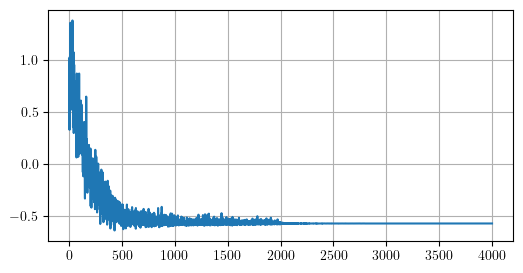

In [10]:
if not laod_pretrained_model:
    
    fig, axs = plt.subplots(1, 1, figsize=(6, 3))

    log_dict = model.trainer.logger.load_numpy()
    plt.plot(log_dict['epoch'], log_dict['loss'], '-')
    # plt.ylim(-7.7, -7.4)
    plt.grid()

## Sampling

### Part A: raw sampling without accept-reject step

Draw one plaquette per lattice site independently from the flow, reshape onto the 2D lattice, then take cumulative products (holonomies) along each direction to reconstruct link variables `U`.

In [10]:
torch.manual_seed(42 * 4 * 32);

In [11]:
import time

In [12]:
lat_shape = (32, 32)
n_samples = 1024

In [13]:
init_time = time.time()

with torch.no_grad():
    Plaq, logq = model.posterior.sample_(n_samples * np.prod(lat_shape))


print("Total time for NF sample generation: %.1f sec" % (time.time() - init_time))


logp = - model.action(Plaq)

Total time for NF sample generation: 0.6 sec


In [14]:
# Reshape to target lattice shape
Plaq = Plaq.reshape(n_samples, *lat_shape, n_c, n_c)
logq = logq.reshape(n_samples, *lat_shape)
logp = logp.reshape(n_samples, *lat_shape)

In [15]:
from lattice_ml.functions import matrix_cumprod

In [16]:
Holonomy = matrix_cumprod(Plaq, dim=1, prepend_identity=True)
Holonomy = matrix_cumprod(Holonomy, dim=2, prepend_identity=True)

In [17]:
Holonomy.shape

torch.Size([1024, 33, 33, 2, 2])

In [18]:
# Perform semi-global symmetry transformation

rotate_0 = model.prior.sample(n_samples * (1 + lat_shape[0])).reshape(-1, (1 + lat_shape[0]), 1, n_c, n_c)
rotate_1 = model.prior.sample(n_samples * (1 + lat_shape[1])).reshape(-1, 1, (1 + lat_shape[1]), n_c, n_c)

Holonomy = (rotate_0 @ Holonomy @ rotate_1)

In [19]:
from lattice_ml.gauge_tools import holonomy_to_link

In [20]:
U, log_prob_corner = holonomy_to_link(Holonomy.unsqueeze(3), return_log_prob=True)

In [21]:
U.shape

torch.Size([1024, 32, 32, 2, 2, 2])

In [22]:
from lattice_ml.gauge_tools import WilsonGaugeAction


action_for_2dim_lattice = WilsonGaugeAction(beta=beta)

In [23]:
logq_2dim = logq.sum(dim=(1, 2))
logp_2dim = - action_for_2dim_lattice(U)

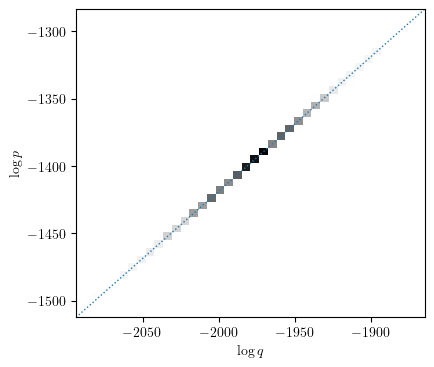

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4))

plt.hist2d(grab(logq_2dim), grab(logp_2dim), bins=40, cmap='Greys')
plt.xlabel(r'$\log q$')
plt.ylabel(r'$\log p$')
    
# Diagonal: logp = logq + constant 
xmin = logq_2dim.min()
xmax = logq_2dim.max()

shift = logp_2dim.mean() - logq_2dim.mean()
plt.plot([xmin, xmax], [xmin + shift, xmax + shift], ':', linewidth=1);


# fig.savefig("SU2_logq_logp.pdf", dpi=600)

Effective sample size (ESS) of the raw flow samples, based on $\log(q) - \log (p)$ of the full 2D lattice.

In [25]:
from lattice_ml.stats import compute_ess

In [26]:
compute_ess(logq_2dim, logp_2dim)

tensor(0.9938)

### Part B: Sampling with accept-reject step implemented

We take the sample generate in Part A and apply Hastings-Metropolis accept/reject step.

In [27]:
from lattice_ml.stats import apply_metropolis_hastings_accept_reject

In [28]:
Plaq_accepted, logq_accepted, logp_accepted, status_seq = apply_metropolis_hastings_accept_reject(Plaq, logq, logp)

The actual acceptance rate based on $\log(q) - \log (p)$ of individual plaquettes.

In [29]:
print(f"acceptance rate: {status_seq.to(torch.float).mean():.4g}")

acceptance rate: 0.9988


In [30]:
Holonomy = matrix_cumprod(Plaq_accepted, dim=1, prepend_identity=True)
Holonomy = matrix_cumprod(Holonomy, dim=2, prepend_identity=True)

U, log_prob_corner = holonomy_to_link(Holonomy.unsqueeze(3), return_log_prob=True)

## Generate HMC data for tests

Independent HMC chain (hot start, 100 thermalization steps) used as a ground-truth cross-check for the flow-based samples.

In [31]:
# Setup HMC

from lattice_ml.monte_carlo import SUnHMC

hmc = SUnHMC(
    lambda t, q: action_for_2dim_lattice.algebra_force(q),
    t_span=(0, 1),
    num_steps=20,
    action=action_for_2dim_lattice
)

In [32]:
# Set initial configuration & number of thermalization steps

full_prior = UniformSUnPrior(n=n_c, shape=(*lat_shape, len(lat_shape)))

hmc_samples = full_prior.sample(n_samples)  # initial hot start

n_thermalization = 100

In [33]:
from lattice_ml.gauge_tools import compute_mean_normalized_trace_wilson_mxn_loop


def format_1(x, sig=3):
    return f"{x.item():#.{sig}g}"

    
def format_2(x, dx):
     return f"{x.item():.4f}({10_000 * dx.item():0.0f})"


def make_progress_report(n_iter, U, is_accepted, delta=None):
    """
    Prepare a progress report for the HMC run.
    """
    str0 = f"{torch.mean(is_accepted.float()).item():.3f}"
    
    plaq = compute_mean_normalized_trace_wilson_mxn_loop(U, 1, 1)
    plaq_mean = plaq.mean()
    plaq_std = plaq.std()
    plaq_error = plaq_std / len(plaq)**0.5
    str1 = format_2(plaq_mean, plaq_error)

    w_22 = compute_mean_normalized_trace_wilson_mxn_loop(U, 2, 2)
    w_22_mean = w_22.mean()
    w_22_std = w_22.std()
    w_22_error = w_22_std / len(w_22)**0.5
    str2 = format_2(w_22_mean, w_22_error)

    if delta is None:
        return f"{n_iter}\t{str0}\t{str1}\t{str2}"
        
    # dH and exp(-dH), each as mean +/- std; std is the batch spread, not a
    # bootstrap error on the mean like the mean(error) pairs in str1
    str3_dh = f"{format_1(torch.mean(delta))} \u00b1 {format_1(torch.std(delta), sig=2)}"
    exp_delta = torch.exp(-delta)
    str3_exp_dh = f"{format_1(torch.mean(exp_delta))} \u00b1 {format_1(torch.std(exp_delta), sig=2)}"
    str3 = f"{str3_dh}\t{str3_exp_dh}"

    return f"{n_iter}\t{str0}\t{str1}\t{str2}\t{str3}"
    

progress_report_header = "n_iter\tAccep\tW_11\t\tW_22\t\tdH\t\texp(-dH)"

**Interpreting the last two columns in the report.** `delta` is $\Delta H = H_{new} - H_{old}$, the Hamiltonian (action + kinetic energy) change accumulated by the leapfrog trajectory *before* the accept/reject test. For any reversible, volume-preserving integrator, the identity $\langle e^{-\Delta H} \rangle = 1$  holds exactly, regardless of step size --- so $\langle e^{-\Delta H} \rangle$ settling to 1.000 is a correctness check on the HMC implementation itself, not a physics result.


`mean(dH)` and `std(dH)` are the discretization-error diagnostics for the chosen step size. If ΔH is approximately Gaussian over the batch, the exact identity above implies mean(ΔH) ≈ ½·Var(ΔH) — this holds well in the data, confirming the integrator is in the small-step-size regime where ΔH errors are Gaussian and well-controlled.

In [34]:
t_0 = time.time()

print(progress_report_header)

for n_iter in range(1, 1 + n_thermalization):
    
    hmc_samples, is_accepted, delta = hmc.step(hmc_samples, return_delta_energy=True)

    
    if n_iter == 1 or n_iter % 10 == 0:
        print(make_progress_report(n_iter, hmc_samples, is_accepted, delta))
        

print(f"Total time: {time.time() - t_0}")

n_iter	Accep	W_11		W_22		dH		exp(-dH)
1	1.000	0.3935(4)	0.0575(5)	-3.17 ± 0.25	24.7 ± 6.2
10	0.938	0.6566(3)	0.1867(6)	0.00964 ± 0.15	1.00 ± 0.15
20	0.935	0.6579(3)	0.1878(6)	0.0147 ± 0.15	0.996 ± 0.15
30	0.937	0.6585(3)	0.1871(6)	0.0108 ± 0.16	1.00 ± 0.16
40	0.938	0.6584(3)	0.1881(6)	0.00583 ± 0.15	1.01 ± 0.15
50	0.944	0.6580(3)	0.1882(6)	0.0126 ± 0.15	0.999 ± 0.16
60	0.935	0.6581(3)	0.1869(6)	0.0223 ± 0.16	0.990 ± 0.16
70	0.945	0.6577(3)	0.1865(6)	0.0150 ± 0.16	0.997 ± 0.16
80	0.938	0.6579(3)	0.1878(6)	0.00980 ± 0.15	1.00 ± 0.16
90	0.938	0.6581(3)	0.1870(6)	0.0170 ± 0.15	0.994 ± 0.15
100	0.952	0.6579(3)	0.1879(6)	0.00357 ± 0.15	1.01 ± 0.16
Total time: 619.3447709083557


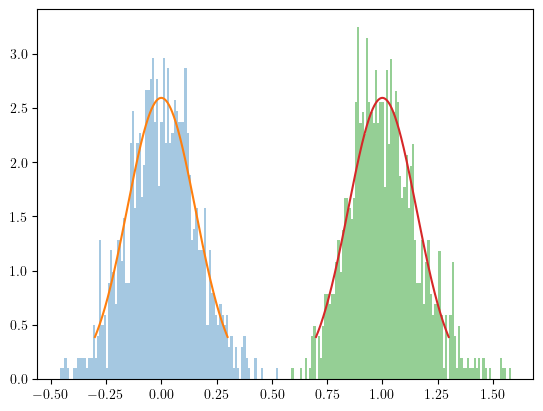

In [35]:
t = torch.linspace(-0.3, 0.3, 1001)


plt.hist(delta.ravel(), bins=100, density=True, alpha=0.4);
s =  torch.var(delta.ravel())
plt.plot(t, torch.exp(-0.5 * t**2 / s) / torch.sqrt(2 * torch.pi * s))
                                                    
plt.hist(torch.exp(-delta).ravel(), bins=100, density=True, alpha=0.5);
s = torch.var(delta.ravel())
plt.plot(1 + t, torch.exp(-0.5 * t**2 / s) / torch.sqrt(2 * torch.pi * s));

In [36]:
from lattice_ml.gauge_tools import compute_mean_normalized_trace_wilson_mxn_loop


def estimate_wilson_loops(x, nm_list):
    
    n = len(nm_list)
    mean = torch.zeros(n)
    std = torch.zeros(n)
    error = torch.zeros(n)
    string = [None] * n

    format_to_string = lambda a, b: f"{a:.4f}({10_000 * b:0.0f})"
    
    ind = 0
    for ind, (m, n) in enumerate(mn_list):
        w_mxn = compute_mean_normalized_trace_wilson_mxn_loop(x, m, n, prefix_dims=1)
        mean[ind] = w_mxn.mean()
        std[ind] = w_mxn.std() 
        error[ind] = std[ind] / x.shape[0] ** 0.5
        string[ind] = format_to_string(mean[ind].item(), error[ind].item())
    
    w_mxn_dict = {'mean': mean, 'std': std, 'error': error, 'str': string}
    
    return w_mxn_dict

In [37]:
from lattice_ml.stats import estimate_expectation_with_importance_sampling


def estimate_wilson_loops_with_importance_sampling(x, nm_list, logq, logp):
    
    n = len(nm_list)
    mean = torch.zeros(n)
    std = torch.zeros(n)
    error = torch.zeros(n)
    string = [None] * n

    format_to_string = lambda a, b: f"{a:.4f}({10_000 * b:0.0f})"
    
    ind = 0
    for ind, (m, n) in enumerate(mn_list):
        w_mxn = compute_mean_normalized_trace_wilson_mxn_loop(x, m, n, prefix_dims=1)
        mean[ind], std[ind], error[ind] = estimate_expectation_with_importance_sampling(
            w_mxn, logq, logp
        )
        string[ind] = format_to_string(mean[ind].item(), error[ind].item())
    
    w_mxn_dict = {'mean': mean, 'std': std, 'error': error, 'str': string}
    
    return w_mxn_dict

### Compare m×n Wilson loops between NF and HMC samples

In [38]:
mn_list = [(1, 1), (1, 2), (1, 3), (1, 4), (2, 2), (2, 3), (2, 4), (3, 3)]

w_mxn_dict_hmc = estimate_wilson_loops(hmc_samples, mn_list)

w_mxn_dict_nf = estimate_wilson_loops(U, mn_list)
w_mxn_dict_nf_importance = estimate_wilson_loops_with_importance_sampling(U, mn_list, logp_2dim - log_prob_corner, logp_2dim)

In [39]:
print("mn\t", "\t".join([f'{str(mn):<10}' for mn in mn_list]))
print()
print("HMC\t", "\t".join(w_mxn_dict_hmc['str']))
print("NF\t",  "\t".join(w_mxn_dict_nf['str']))
print("NF:i\t", "\t".join(w_mxn_dict_nf_importance['str']))

mn	 (1, 1)    	(1, 2)    	(1, 3)    	(1, 4)    	(2, 2)    	(2, 3)    	(2, 4)    	(3, 3)    

HMC	 0.6579(3)	0.4330(4)	0.2848(5)	0.1870(5)	0.1879(6)	0.0811(5)	0.0346(5)	0.0229(6)
NF	 0.6584(3)	0.4335(4)	0.2854(5)	0.1874(5)	0.1877(6)	0.0811(5)	0.0351(5)	0.0227(6)
NF:i	 0.6585(3)	0.4335(5)	0.2854(6)	0.1876(6)	0.1876(7)	0.0809(7)	0.0353(6)	0.0227(7)


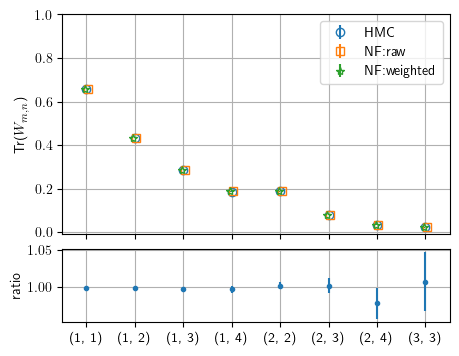

In [40]:
def log_ratio(a, da, b, db):
    """
    Return log(a / b) and its error given `a`, `b`, and their errors. 
    """
    c = torch.log(a / b)
    dc = torch.sqrt((da / a)**2 + (db / b)**2)
    return c, dc
    

def ratio(a, da, b, db):
    """
    Return log(a / b) and its error given `a`, `b`, and their errors. 
    """
    c = a / b
    dc = c * torch.sqrt((da / a)**2 + (db / b)**2)
    return c, dc
    

def plot_observables(mn_list, w_mxn_dict_hmc, w_mxn_dict_nf, w_mxn_dict_nf_weighted):

    fig, axs = plt.subplots(2, 1, figsize=(5, 4), gridspec_kw={'height_ratios': [0.75, 0.25]})

    y0 = w_mxn_dict_hmc['mean']
    dy0 = w_mxn_dict_hmc['error']
    y1 = w_mxn_dict_nf['mean']
    dy1 = w_mxn_dict_nf['error']
    y2 = w_mxn_dict_nf_weighted['mean']
    dy2 = w_mxn_dict_nf_weighted['error']

    x = np.arange(len(mn_list))
    axs[0].errorbar(x,        y0, dy0, fmt='o', markerfacecolor='none', label='HMC')
    axs[0].errorbar(x + 0.03, y1, dy1, fmt='s', markerfacecolor='none', label='NF:raw')
    axs[0].errorbar(x - 0.03, y2, dy2, fmt='*', markerfacecolor='none', label='NF:weighted')


    c, dc = ratio(y0, dy0, y2, dy2)
    axs[1].errorbar(x, c, dc, fmt='.', label='ratio')

    # Add title & labels
    axs[0].set_ylabel(r"Tr($W_{m, n}$)")
    for k in range(2):
        axs[k].grid()
    
    axs[0].legend()
    axs[1].set_ylabel('ratio')
    
    # Set xlim & ylim and remove undesired axis ticks
    for k in range(2):
        axs[k].set_xticks(x)
        axs[k].set_xticklabels(mn_list)
        axs[k].set_xlim([-0.5, len(x) - 0.5])
        
    axs[0].set_xticklabels(['' for _ in x])
    axs[0].set_yticks(np.linspace(0, 1, 6))

    # Decrease horizontal spacing between subplots
    plt.subplots_adjust(hspace=0.1)

    return fig, axs


fig, axs = plot_observables(mn_list, w_mxn_dict_hmc, w_mxn_dict_nf, w_mxn_dict_nf_importance)


fig.savefig(f"SU2_Wilson_loops_measurment_32x32_beta{beta}.pdf", dpi=600)

In [41]:
compute_ess(logp_2dim - log_prob_corner, logp_2dim)

tensor(0.6841)